# Tarea ARIMA - Gasolina

In [21]:
import numpy as np
import pandas as pd
from io import StringIO
import contextlib
import re
import matplotlib.pyplot as plt
plt.style.use('default')

# pmdarima
from pmdarima import ARIMA
from pmdarima import auto_arima

# statsmodels
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# skforecast
from skforecast.stats import Sarimax
from skforecast.recursive import ForecasterStats
from skforecast.model_selection import backtesting_stats
from skforecast.model_selection import grid_search_stats
from sklearn.metrics import mean_absolute_error
import seaborn as sns
import warnings

In [18]:
# Descarga datos
url = ('https://raw.githubusercontent.com/JoaquinAmatRodrigo/Estadistica-machine-learning-python/'
 'master/data/consumos-combustibles-mensual.csv')
datos_t = pd.read_csv(url, sep=',')
datos_t = datos_t[['Fecha', 'Gasolinas']]
datos_t = datos_t.rename(columns={'Fecha':'date', 'Gasolinas':'litters'})
datos_t['date'] = pd.to_datetime(datos_t['date'], format='%Y-%m-%d')
datos_t = datos_t.set_index('date')
datos = datos_t.loc[:'1980-01-01 00:00:00']
datos = datos.asfreq('MS')
datos = datos['litters']
datos.head()

date
1969-01-01    166875.2129
1969-02-01    155466.8105
1969-03-01    184983.6699
1969-04-01    202319.8164
1969-05-01    206259.1523
Freq: MS, Name: litters, dtype: float64

Text(0.5, 1.0, 'Consumo mensual de gasolina')

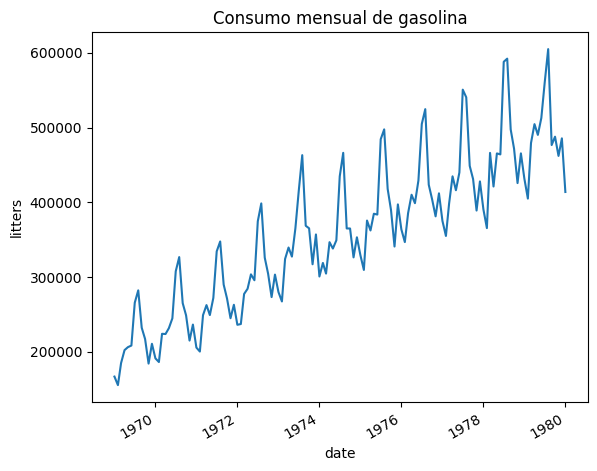

In [22]:
sns.lineplot(datos)
plt.xticks(rotation=30, ha='right')
# Ajustes de diseño
plt.title('Consumo mensual de gasolina')

No es estacionaria
Es homocedástica
Tendencia creciente clara
Exisiten ciclos anuales, periodo 12

### Diferenciamos la serie

Text(0.5, 1.0, 'Serie diferenciada de orden 1')

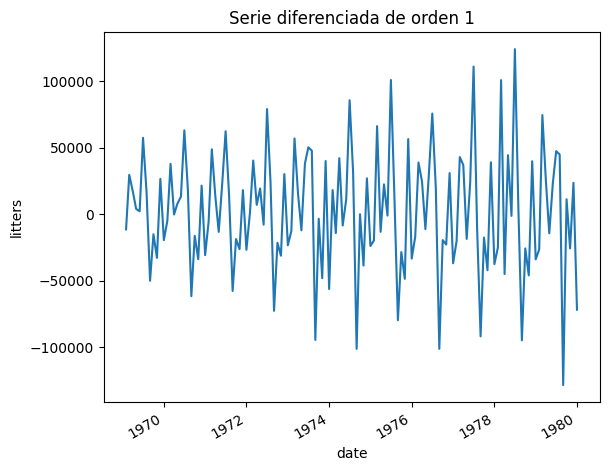

In [23]:
datos = datos.diff().dropna()
sns.lineplot(datos)
plt.xticks(rotation=30, ha='right')
# Ajustes de diseño
plt.title('Serie diferenciada de orden 1')

Text(0.5, 1.0, 'PACF serie diferenciada')

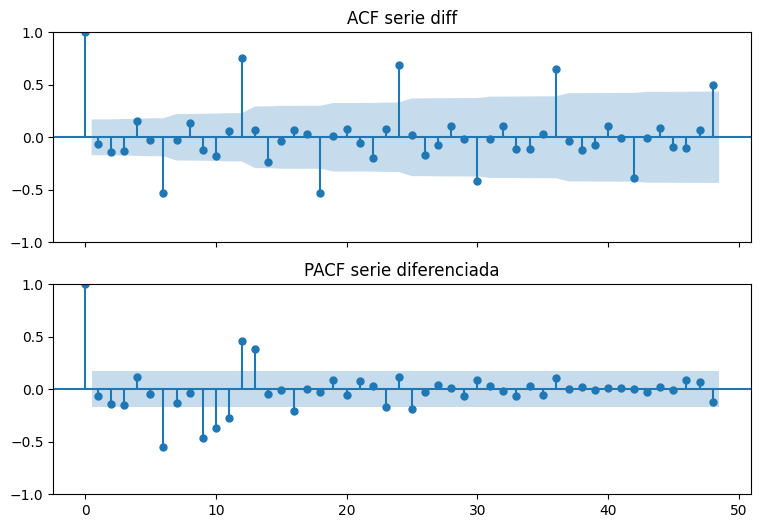

In [33]:
fig, axs = plt.subplots(nrows=2, ncols=1,
figsize=(9, 6), sharex=True)
plot_acf(datos, ax=axs[0],
lags=48, alpha=0.05)
axs[0].set_title('ACF serie diff')
plot_pacf(datos, ax=axs[1],
lags=48, alpha=0.05)
axs[1].set_title('PACF serie diferenciada')

In [30]:
adf_result = adfuller(datos)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -3.6417276900323126
p-value: 0.005011605002137415


In [31]:
kpss_result = kpss(datos, regression='c')

print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])

KPSS Statistic: 0.05268059379842924
p-value: 0.1


C:\Users\eloyc\AppData\Local\Temp\ipykernel_33984\2972970862.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(datos, regression='c')


Vemos que el test de Dickey Fuller rechaza H0, por lo que la serie diferenciada es estacionaria
Por tanto d=1

### Diferenciamos por orden 12 ahora